In [26]:
from __future__ import annotations
from dataclasses import dataclass, field
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

for candidate in (Path.cwd(), Path.cwd().parent):
    pymrm_src = candidate / "pymrm" / "src"
    if pymrm_src.exists() and str(pymrm_src) not in sys.path:
        sys.path.insert(0, str(pymrm_src))

from pymrm import (
    NumJac,
    construct_coefficient_matrix,
    construct_convflux_upwind,
    construct_div,
    construct_grad,
    newton,
    non_uniform_grid,
)


In [ ]:

@dataclass
class ModelConfig:
    length: float = 1.0 # length
    R_ret: float = 5e-3 # radius of retentate
    R_perm: float = R_ret + 5e-4 # radius of permeate
    R_out: float = 7e-3 # outer radius

    P_vector: np.ndarray = field(default_factory=lambda: np.array([0.000, 0.000, 0.000, 0.02, 0.000])) # membrane permeability
    v_ret: float = 1e-1 # velocity of retentate
    v_perm: float = 1e-1 # velocity of permeate
    d_ax: float = 2.0e-5 # dispersion in the axial direction
    
    n_z: int = 100 # number of grid points in the axial direction
    n_r_perm: int = 30 # number of grid points in the radial direction of permeate
    n_r_ret: int = 30 # number of grid points in the radial direction of retentate
    n_c: int = 5 # number of components
    
    particle_radius: float = 1.0e-3 # catalyst particle radius
    particle_diffusivity: np.ndarray = field(default_factory=lambda: np.array([2.0e-6, 1.5e-6, 1.5e-6, 1.5e-6, 1.5e-6]))   # diffusivity in the particle per component
    eps_s: float = 0.35  # solid holdup

    eps_bed: float = 0.4 # bed porosity
    mu: float = 1.0e-3 # viscosity of the gas
    dp: float = 2.0e-3 # particle diameter
    T: float = 300.0 # temperature
    R: float = 8.314 # gas constant
    P_in: float = 1.0 # inlet pressure

    k_1: float = 2.0   #  reaction rate constant for reaction 1
    k_2: float = 1.0   #  reaction rate constant for backward reaction 1
    k_3: float = 2.0   #  reaction rate constant for reaction 2
    k_4: float = 1.0   #  reaction rate constant for backward reaction 2

    inlet_concentration: np.ndarray = field(default_factory=lambda: np.array([1.0, 3.0, 0.0, 0.0, 0.0])) # inlet concentration of the components, CO2, H2, CH3OH, H2O, DMC
    film_pair_coefficients: np.ndarray = field(  # mass transfer coefficients for the film model, in the order of (CO2, H2, CH3OH, H2O, DMC)
        default_factory=lambda: np.array( 
            [
                [np.inf, 2.0e-3, 2.0e-3, 2.0e-3, 2.0e-3],
                [2.0e-3, np.inf, 4.0e-3, 3.0e-3, 2.5e-3],
                [2.0e-3, 4.0e-3, np.inf, 3.5e-3, 2.0e-3],
                [2.0e-3, 3.0e-3, 3.5e-3, np.inf, 2.2e-3],
                [2.0e-3, 2.5e-3, 2.0e-3, 2.2e-3, np.inf],
                
            ]
        )
    ) # k_ij pair diffusion coefficient
    tol: float = 1.0e-8  # tolerance for convergence
    maxfev: int = 20    # maximum number of function evaluations

    @property # external paricle surface area per unit bed volume
    def external_area(self):
        return 3.0 * self.eps_s / self.particle_radius

    @property # Maxwell-Stefan k_ij * a_vO2, H2, CH3OH, H2O, DMC)
    def kma(self):
        return self.film_pair_coefficients * self.external_area
    
    @property # Membrane interfacial area per unit volume of retentate tube (2 π R_ret L / (π R_ret² L) = 2 / R_ret )
    def a_ret(self):
        return 2.0 / self.R_ret
    
    @property # membrane area per unit volume of the permeate (2 π R_ret L / (π (R_out² - R_perm²) L) = 2 R_ret / (R_out² - R_perm²))
    def a_perm(self):
        return 2.0 * self.R_ret / (self.R_out**2 - self.R_perm**2)

cfg = ModelConfig()

pd.Series(
    {
        "axial cells": cfg.n_z,
        "particle radial cells": [cfg.n_r_ret, cfg.n_r_perm],
        "reactor length [m]": cfg.length,
        "velocity [m/s]": [cfg.v_perm, cfg.v_ret],
        "particle radius [mm]": 1e3 * cfg.particle_radius,
        "solid holdup [-]": cfg.eps_s,
        "external area [1/m]": cfg.external_area,
        "retentate area [1/m]": cfg.a_ret,
        "permeate area [1/m]": cfg.a_perm,
        "reaction rate constant [1/s]": [cfg.k_1, cfg.k_2, cfg.k_3, cfg.k_4], 
    },
    name="settings",
)

axial cells                                      100
particle radial cells                       [30, 30]
reactor length [m]                               1.0
velocity [m/s]                            [0.1, 0.1]
particle radius [mm]                             1.0
solid holdup [-]                                0.35
external area [1/m]                           1050.0
retentate area [1/m]                           400.0
permeate area [1/m]                       533.333333
reaction rate constant [1/s]    [2.0, 1.0, 2.0, 1.0]
Name: settings, dtype: object

In [ ]:
class ReactorParticleMaxwellStefanModel:
    species_labels = ("CO2", "H2", "CH3OH", "H2O", "DMC") # CO2, H2, CH3OH, H2O, DMC
    stoich = np.array([[-1.0, -3.0, 1.0, 1.0, 0.0], # r1: A + 3B <-> C + D
                      [-1.0, 0.0, -2.0, 1.0, 1.0]]) # r2: A + 2C <-> D + E 

    def __init__(self, cfg: ModelConfig): 
        self.cfg = cfg
        self.ret_shape = (cfg.n_z, cfg.n_c) # col 0 : retentate bulk gas
        self.gas_shape = self.ret_shape
        self.boundary_shape = (cfg.n_z, 1, cfg.n_c) # col 1:  film/boundary layer
        self.particle_shape = (cfg.n_z, cfg.n_r_ret, cfg.n_c) # cols2 ... n_r+r : particle interior
        self.shape = (cfg.n_z, cfg.n_r_ret + 3, cfg.n_c) # total columns: 1(gas) + 1(film) + n_r_ret(particle interior) + 1(permeate)
        self._build_grids()
        self._build_operators()
        self.numjac = NumJac(self.shape, axes_diagonals=[0], axes_blocks=[1, 2])
        self.u0 = self.initial_state()
        self.u = self.u0.copy()
        
    def _build_grids(self):
        cfg = self.cfg
        self.z_f = np.linspace(0.0, cfg.length, cfg.n_z + 1) # axial grid
        self.z_c = 0.5 * (self.z_f[:-1] + self.z_f[1:])
        self.r_f_ret = non_uniform_grid(0.0, cfg.particle_radius, cfg.n_r_ret + 1, 0.15 * cfg.particle_radius, 0.75) # non uniform radial grid in retentate
        self.r_c_ret = 0.5 * (self.r_f_ret[:-1] + self.r_f_ret[1:])
        self.r_f_perm = non_uniform_grid(cfg.R_ret, cfg.R_perm, cfg.n_r_perm + 1, 0.15 * (cfg.R_perm - cfg.R_ret), 0.75) # non uniform radial grid in permeate
        self.r_c_perm = 0.5 * (self.r_f_perm[:-1] + self.r_f_perm[1:])
        self.volume_weights = np.diff(self.r_f_ret**3) / self.r_f_ret[-1] ** 3

    def _build_operators(self):
        cfg = self.cfg
        
        bc_axial = (
            {"a": 0.0, "b": 1.0, "d":cfg.inlet_concentration}, # dirchlet
            {"a": 1.0, "b": 0.0, "d": 0.0}, # Neumann
        )
        grad_mat_ret, grad_bc_ret = construct_grad(self.gas_shape, self.z_f, self.z_c, bc=bc_axial, axis=0)
        conv_mat_ret, conv_bc_ret = construct_convflux_upwind(self.gas_shape, self.z_f, self.z_c, bc=bc_axial, v=cfg.v_ret, axis=0)
        div_mat_ret = construct_div(self.gas_shape, self.z_f, axis=0)
        d_ax_mat_ret = construct_coefficient_matrix(cfg.d_ax, self.gas_shape, axis=0)
        self.gas_transport_mat = div_mat_ret @ (conv_mat_ret - d_ax_mat_ret @ grad_mat_ret)
        self.gas_transport_const = div_mat_ret @ (conv_bc_ret - d_ax_mat_ret @ grad_bc_ret)

        bc_particle = (
            {"a": 1.0, "b": 0.0, "d": 0.0}, # dirichlet at the center of the particle
            {"a": 0.0, "b": 1.0, "d": 1.0}, # Neumann at the outer edge of the particle
        )

        #shape of div and grad: (n_z * n_r_ret * n_c, n_z * n_r_ret * n_c), shape of grad_bc: (n_z * 1 * n_c, n_z * n_r_ret * n_c)
        grad_p_mat, _, grad_p_bc = construct_grad(self.particle_shape, self.r_f_ret, self.r_c_ret, bc=bc_particle, axis=1, shapes_d=(None, self.boundary_shape),)
        div_p_mat = construct_div(self.particle_shape, self.r_f_ret, nu=2, axis=1)
        d_p = cfg.particle_diffusivity.reshape(1, 1, cfg.n_c)
        d_p_mat = construct_coefficient_matrix(d_p, self.particle_shape, axis=1)
        flux_p_mat = -d_p_mat @ grad_p_mat # difusive flux matrix in the particle interior
        flux_p_bc = -d_p_mat @ grad_p_bc # diffusive flux contribution from bc
        self.particle_diffusion_mat = div_p_mat @ flux_p_mat
        self.particle_boundary_mat = div_p_mat @ flux_p_bc

        face_shape = (cfg.n_z, cfg.n_r_ret + 1, cfg.n_c)
        outer_face_rows = (
            face_shape[2] * face_shape[1] * np.arange(face_shape[0]).reshape((-1, 1))
            + face_shape[2] * cfg.n_r_ret
            + np.arange(face_shape[2]).reshape((1, -1))
        ).ravel()
        self.particle_apparent_mat = (3.0 / cfg.particle_radius) * flux_p_mat[outer_face_rows, :]
        self.particle_apparent_bc_mat = (3.0 / cfg.particle_radius) * flux_p_bc[outer_face_rows, :]

        # bc_perm_inlet = cfg.v_perm * np.zeros(cfg.n_c) 
        bc_permeate = (
            {"a": 0.0, "b": 1.0, "d": 0.0}, # c_m = 0 at z = 0 (Dirichlet)
            {"a": 1.0, "b": 0.0, "d": 0.0}, # dc_m/dz = 0 at z = L (Neumann)
        )
        conv_mat_m, conv_bc_m = construct_convflux_upwind(self.gas_shape, self.z_f, self.z_c, bc=bc_permeate, v=cfg.v_perm, axis=0)
        div_mat_m = construct_div(self.gas_shape, self.z_f, axis=0)
        self.perm_transport_mat = div_mat_m @ conv_mat_m
        self.perm_transport_const = div_mat_m @ conv_bc_m 

    def initial_state(self): # intitialise retatentate, film, particle interior, permeate
        u = np.zeros(self.shape)
        u[:, :-1, :] = self.cfg.inlet_concentration.reshape(1, 1, self.cfg.n_c)
        u[:, -1, :] = 0.0
        return u

    def split_state(self, u): # flat state vector to fields (gas, boundary, particle interior, permeate)
        u = u.reshape(self.shape)
        return u[:, 0, :], u[:, 1, :], u[:, 2:-1, :], u[:, -1, :]
    
    def particle_source(self, c_p): # reaction source term in the particle, shape (n_z, n_r_ret, n_c)
        r1 = (self.cfg.k_1 * c_p[..., 0] * (c_p[..., 1]**3) - self.cfg.k_2 * c_p[..., 2] * c_p[..., 3])
        r2 = (self.cfg.k_3 * c_p[..., 0] * (c_p[..., 2]**2) - self.cfg.k_4 * c_p[..., 4] * c_p[..., 3])
        
        rates = np.stack([r1, r2], axis=-1)
        return np.einsum('zrc,co->zro', rates, self.stoich)

    def particle_average_source(self, c_p): # average reaction source term in the particle, shape (n_z, n_c)
        source = self.particle_source(c_p)
        return np.sum(source * self.volume_weights.reshape(1, -1, 1), axis=1)

    def particle_apparent_source(self, c_p, c_b): # apparent reaction source term in the particle, shape (n_z, n_c)
        c_p_vec = c_p.reshape(-1, 1)
        c_b_vec = c_b[:, None, :].reshape(-1, 1)
        return (
            self.particle_apparent_mat @ c_p_vec
            + self.particle_apparent_bc_mat @ c_b_vec
        ).reshape(self.gas_shape)

    def maxwell_stefan_film_residual(self, c_g, c_b, source_reactor):
        c_mid = 0.5 * (c_g + c_b)
        y_mid = c_mid / np.maximum(np.sum(c_mid, axis=-1, keepdims=True), 1.0e-30)
        correction = np.zeros_like(c_g)
        for i in range(self.cfg.n_c):
            for j in range(self.cfg.n_c):
                if i != j:
                    correction[:, i] += (
                        y_mid[:, j] * source_reactor[:, i]
                        - y_mid[:, i] * source_reactor[:, j]
                    ) / self.cfg.kma[i, j]
        return c_b - c_g - correction

    def residual_values(self, u):
        # Block layout (matching self.shape):
          # [0]    retentate bulk ADE  +  membrane sink
          # [1]    Maxwell–Stefan film equation
          # [2:-1] particle diffusion–reaction
          # [-1]   permeate convection  +  membrane source
        c_g, c_b, c_p, c_m = self.split_state(u) 
        source_particle = self.particle_source(c_p)
        source_reactor = self.cfg.eps_s * self.particle_apparent_source(c_p, c_b)
        p_mask = self.cfg.P_vector.reshape(1, -1)
        membrane_flux_density = p_mask * (c_g - c_m)
        residual = np.zeros_like(u).reshape(self.shape)
        residual[:, 0, :] = (
            self.gas_transport_const
            + self.gas_transport_mat @ c_g.reshape(-1, 1)
        ).reshape(self.gas_shape) - source_reactor + (self.cfg.a_ret * membrane_flux_density)
        residual[:, 1, :] = self.maxwell_stefan_film_residual(c_g, c_b, source_reactor)
        residual[:, 2:-1, :] = (
            self.particle_diffusion_mat @ c_p.reshape(-1, 1)
            + self.particle_boundary_mat @ c_b[:, None, :].reshape(-1, 1)
        ).reshape(self.particle_shape) - source_particle
        residual[:, -1, :] = (
            self.perm_transport_const + self.perm_transport_mat @ c_m.reshape(-1, 1)
        ).reshape(self.gas_shape) - (self.cfg.a_perm * membrane_flux_density)
        return residual

    def residual(self, u):
        u = u.reshape(self.shape)
        residual = self.residual_values(u)
        residual, jac = self.numjac(self.residual_values, u, f_value=residual)
        return residual.ravel(), jac

    def solve(self):
        result = newton(self.residual, self.u, tol=self.cfg.tol, maxfev=self.cfg.maxfev, solver="spsolve")
        self.u = result.x.reshape(self.shape)
        self.result = result
        return result

    def fields(self):
        return self.split_state(self.u)

    def effectiveness_profile(self, eps: float = 1.0e-12):
        _c_g, c_b, c_p, _c_m = self.fields()

        w = self.volume_weights.reshape(1, -1)

        r1_fwd_local = self.cfg.k_1 * c_p[..., 0] * (c_p[..., 1] ** 3)
        r1_bwd_local = self.cfg.k_2 * c_p[..., 2] * c_p[..., 3]
        r1_net_local = r1_fwd_local - r1_bwd_local

        r2_fwd_local = self.cfg.k_3 * c_p[..., 0] * (c_p[..., 2] ** 2)
        r2_bwd_local = self.cfg.k_4 * c_p[..., 4] * c_p[..., 3]
        r2_net_local = r2_fwd_local - r2_bwd_local

    # Volume-averaged apparent rates
        r1_app_fwd = np.sum(r1_fwd_local * w, axis=1)
        r1_app_bwd = np.sum(r1_bwd_local * w, axis=1)
        r1_app_net = np.sum(r1_net_local * w, axis=1)

        r2_app_fwd = np.sum(r2_fwd_local * w, axis=1)
        r2_app_bwd = np.sum(r2_bwd_local * w, axis=1)
        r2_app_net = np.sum(r2_net_local * w, axis=1)

    # Surface rates evaluated at pellet boundary concentration c_b
        r1_surf_fwd = self.cfg.k_1 * c_b[:, 0] * (c_b[:, 1] ** 3)
        r1_surf_bwd = self.cfg.k_2 * c_b[:, 2] * c_b[:, 3]
        r1_surf_net = r1_surf_fwd - r1_surf_bwd

        r2_surf_fwd = self.cfg.k_3 * c_b[:, 0] * (c_b[:, 2] ** 2)
        r2_surf_bwd = self.cfg.k_4 * c_b[:, 4] * c_b[:, 3]
        r2_surf_net = r2_surf_fwd - r2_surf_bwd

        def safe_div(num, den, eps):
            out = np.full_like(num, np.nan, dtype=float)
            mask = np.abs(den) > eps
            out[mask] = num[mask] / den[mask]
            return out

        eta_r1_fwd = safe_div(r1_app_fwd, r1_surf_fwd, eps)
        eta_r1_bwd = safe_div(r1_app_bwd, r1_surf_bwd, eps)
        eta_r1_net = safe_div(r1_app_net, r1_surf_net, eps)

        eta_r2_fwd = safe_div(r2_app_fwd, r2_surf_fwd, eps)
        eta_r2_bwd = safe_div(r2_app_bwd, r2_surf_bwd, eps)
        eta_r2_net = safe_div(r2_app_net, r2_surf_net, eps)

        return {
            "eta_r1_net": eta_r1_net,
            "eta_r2_net": eta_r2_net,
            "eta_r1_fwd": eta_r1_fwd,
            "eta_r2_fwd": eta_r2_fwd,
            "eta_r1_bwd": eta_r1_bwd,
            "eta_r2_bwd": eta_r2_bwd,
        }

    
model = ReactorParticleMaxwellStefanModel(cfg)
result = model.solve()
c_g, c_b, c_p, c_m = model.fields()
source_reactor = cfg.eps_s * model.particle_apparent_source(c_p, c_b)

eff = model.effectiveness_profile()

eta_r1_net = eff["eta_r1_net"]
eta_r2_net = eff["eta_r2_net"]
eta_r1_fwd = eff["eta_r1_fwd"]
eta_r2_fwd = eff["eta_r2_fwd"]
eta_r1_bwd = eff["eta_r1_bwd"]
eta_r2_bwd = eff["eta_r2_bwd"]

pd.Series(
    {
        "success": result.success,
        "message": result.message,
        "Newton iterations": result.nit,
        "final residual norm": np.linalg.norm(result.fun, ord=np.inf),
        "minimum concentration [mol/m3]": np.min(model.u),
        "outlet CO2 conversion": 1.0 - c_g[-1, 0] / c_g[0, 0],
        "Outlet H2 conversion": 1.0 - c_g[-1, 1] / c_g[0, 1],
        "Outlet DMC concentration [mol/m3]": c_g[-1, 4],
        "outlet gas c_A [mol/m3]": c_g[-1, 0],
        "outlet boundary c_A [mol/m3]": c_b[-1, 0],
    },
    name="solve summary",
)

success                                   True
message                              Converged
Newton iterations                           10
final residual norm                        0.0
minimum concentration [mol/m3]             0.0
outlet CO2 conversion                 0.814762
Outlet H2 conversion                  0.668203
Outlet DMC concentration [mol/m3]     0.130001
outlet gas c_A [mol/m3]               0.161324
outlet boundary c_A [mol/m3]          0.161051
Name: solve summary, dtype: object

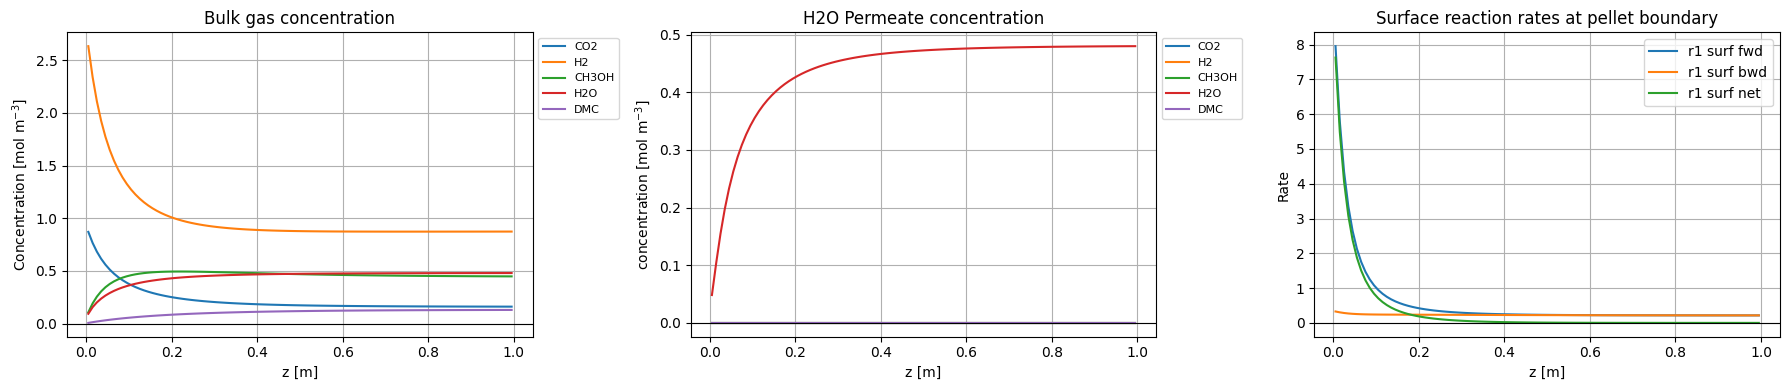

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

for i, label in enumerate(model.species_labels):
    axes[0].plot(model.z_c, c_g[:, i], label=label)
axes[0].axhline(0.0, color="k", linewidth=0.8)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Concentration [mol m$^{-3}$]")
axes[0].set_title("Bulk gas concentration")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), ncol=1, fontsize=8)
axes[0].grid(True)

for i, label in enumerate(model.species_labels):
    axes[1].plot(model.z_c, c_m[:, i], label=label)
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("concentration [mol m$^{-3}$]")
axes[1].set_title("H2O Permeate concentration")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0), ncol=1, fontsize=8)
axes[1].grid(True)

axes[2].plot(model.z_c, eff["r1_surf_fwd"], label="r1 surf fwd")
axes[2].plot(model.z_c, eff["r1_surf_bwd"], label="r1 surf bwd")
axes[2].plot(model.z_c, eff["r1_surf_net"], label="r1 surf net")
axes[2].axhline(0.0, color="k", lw=0.8)
axes[2].set_xlabel("z [m]")
axes[2].set_ylabel("Rate")
axes[2].set_title("Surface reaction rates at pellet boundary")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()



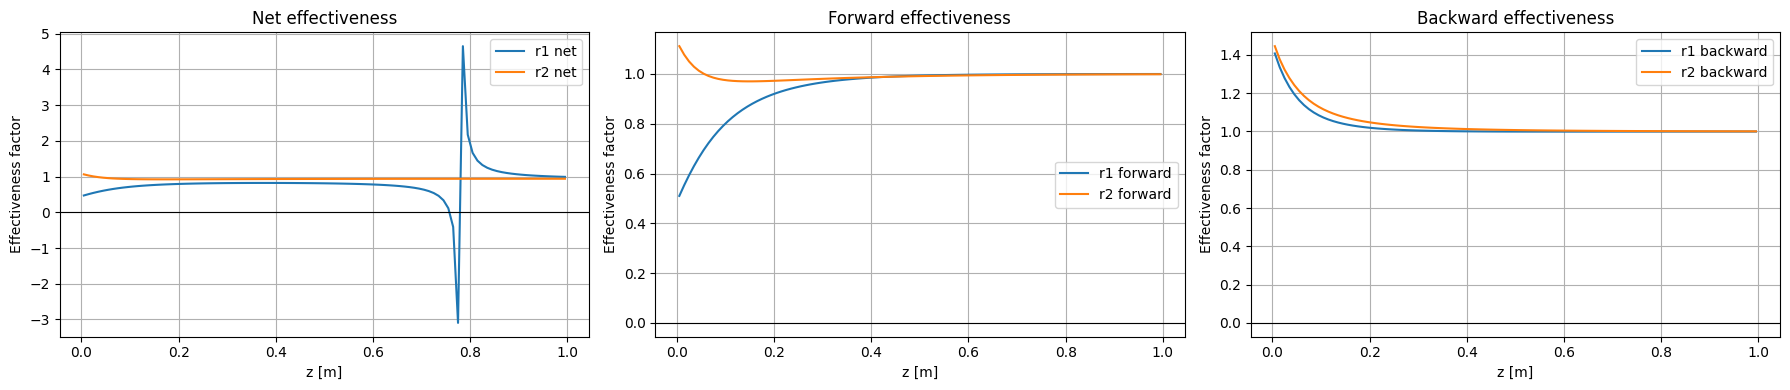

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Net effectiveness
axes[0].plot(model.z_c, eta_r1_net, label="r1 net")
axes[0].plot(model.z_c, eta_r2_net, label="r2 net")
axes[0].axhline(0.0, color="k", linewidth=0.8)
axes[0].set_title("Net effectiveness")
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("Effectiveness factor")
axes[0].grid(True)
axes[0].legend()

# Forward effectiveness
axes[1].plot(model.z_c, eta_r1_fwd, label="r1 forward")
axes[1].plot(model.z_c, eta_r2_fwd, label="r2 forward")
axes[1].axhline(0.0, color="k", linewidth=0.8)
axes[1].set_title("Forward effectiveness")
axes[1].set_xlabel("z [m]")
axes[1].set_ylabel("Effectiveness factor")
axes[1].grid(True)
axes[1].legend()

# Backward effectiveness
axes[2].plot(model.z_c, eta_r1_bwd, label="r1 backward")
axes[2].plot(model.z_c, eta_r2_bwd, label="r2 backward")
axes[2].axhline(0.0, color="k", linewidth=0.8)
axes[2].set_title("Backward effectiveness")
axes[2].set_xlabel("z [m]")
axes[2].set_ylabel("Effectiveness factor")
axes[2].grid(True)
axes[2].legend()



plt.tight_layout()
plt.show()